1. Importar librerías y cargar datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Cargar los archivos principales
admissions   = pd.read_csv('data/ADMISSIONS.csv')
patients     = pd.read_csv('data/PATIENTS.csv')
diagnoses    = pd.read_csv('data/DIAGNOSES_ICD.csv')
labevents    = pd.read_csv('data/LABEVENTS.csv')
prescriptions = pd.read_csv('data/PRESCRIPTIONS.csv')

print("✅ Archivos cargados correctamente")
print(f"Admissions:    {admissions.shape}")
print(f"Patients:      {patients.shape}")
print(f"Diagnoses:     {diagnoses.shape}")
print(f"Labevents:     {labevents.shape}")
print(f"Prescriptions: {prescriptions.shape}")

✅ Archivos cargados correctamente
Admissions:    (129, 19)
Patients:      (100, 8)
Diagnoses:     (1761, 5)
Labevents:     (76074, 9)
Prescriptions: (10398, 19)


2. Vista general de cada tabla

In [11]:
print("=== ADMISSIONS ===")
print(admissions.dtypes)
print("\n=== PATIENTS ===")
print(patients.dtypes)
print("\n=== DIAGNOSES ===")
print(diagnoses.dtypes)

=== ADMISSIONS ===
row_id                  int64
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admission_location        str
discharge_location        str
insurance                 str
language                  str
religion                  str
marital_status            str
ethnicity                 str
edregtime                 str
edouttime                 str
diagnosis                 str
hospital_expire_flag    int64
has_chartevents_data    int64
dtype: object

=== PATIENTS ===
row_id         int64
subject_id     int64
gender           str
dob              str
dod              str
dod_hosp         str
dod_ssn          str
expire_flag    int64
dtype: object

=== DIAGNOSES ===
row_id        int64
subject_id    int64
hadm_id       int64
seq_num       int64
icd9_code       str
dtype: object


3. Valores nulos por tabla

In [12]:
for nombre, tabla in [("ADMISSIONS", admissions), 
                       ("PATIENTS", patients),
                       ("DIAGNOSES", diagnoses),
                       ("LABEVENTS", labevents),
                       ("PRESCRIPTIONS", prescriptions)]:
    nulos = tabla.isnull().sum()
    porcentaje = (nulos / len(tabla) * 100).round(2)
    missing = pd.DataFrame({
        'Nulos': nulos, 
        'Porcentaje (%)': porcentaje
    }).sort_values('Porcentaje (%)', ascending=False)
    
    print(f"\n=== {nombre} ===")
    print(missing[missing['Nulos'] > 0])


=== ADMISSIONS ===
                Nulos  Porcentaje (%)
deathtime          89           68.99
language           48           37.21
edouttime          37           28.68
edregtime          37           28.68
marital_status     16           12.40
religion            1            0.78

=== PATIENTS ===
          Nulos  Porcentaje (%)
dod_hosp     30            30.0
dod_ssn      23            23.0

=== DIAGNOSES ===
Empty DataFrame
Columns: [Nulos, Porcentaje (%)]
Index: []

=== LABEVENTS ===
          Nulos  Porcentaje (%)
flag      46337           60.91
hadm_id   14262           18.75
valueuom   9405           12.36
valuenum   9044           11.89
value         5            0.01

=== PRESCRIPTIONS ===
                   Nulos  Porcentaje (%)
drug_name_poe       4632           44.55
drug_name_generic   4626           44.49
icustay_id          3352           32.24
gsn                 1276           12.27
formulary_drug_cd      1            0.01
ndc                    1            0.01
f

4. Imputar nulos numéricos con KNN

In [13]:
def imputar_knn(df, nombre):
    numericas = df.select_dtypes(include='number').columns.tolist()
    categoricas = df.select_dtypes(include='object').columns.tolist()
    
    # KNN para numéricas
    if numericas:
        imputer = KNNImputer(n_neighbors=5)
        df_num = pd.DataFrame(
            imputer.fit_transform(df[numericas]),
            columns=numericas
        )
    else:
        df_num = pd.DataFrame()
    
    # Moda para categóricas
    if categoricas:
        df_cat = df[categoricas].fillna(df[categoricas].mode().iloc[0])
    else:
        df_cat = pd.DataFrame()
    
    df_limpio = pd.concat([df_num, df_cat], axis=1)
    total_nulos = df_limpio.isnull().sum().sum()
    print(f"✅ {nombre} — Nulos restantes: {total_nulos}")
    return df_limpio

admissions_limpio    = imputar_knn(admissions, "ADMISSIONS")
patients_limpio      = imputar_knn(patients, "PATIENTS")
diagnoses_limpio     = imputar_knn(diagnoses, "DIAGNOSES")
prescriptions_limpio = imputar_knn(prescriptions, "PRESCRIPTIONS")

✅ ADMISSIONS — Nulos restantes: 0
✅ PATIENTS — Nulos restantes: 0
✅ DIAGNOSES — Nulos restantes: 0


C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\2979753308.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\2979753308.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/d

✅ PRESCRIPTIONS — Nulos restantes: 0


In [14]:
labevents_limpio = imputar_knn(labevents, "LABEVENTS")

C:\Users\Natalia\AppData\Local\Temp\ipykernel_13504\2979753308.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


✅ LABEVENTS — Nulos restantes: 0


5. Estadísticas descriptivas

In [15]:
print("=== ADMISSIONS ===")
display(admissions_limpio.describe().round(2))

print("\n=== PATIENTS ===")
display(patients_limpio.describe().round(2))

=== ADMISSIONS ===


,row_id,subject_id,hadm_id,hospital_expire_flag,has_chartevents_data
count,129.00,129.00,129.00,129.00,129.00
mean,28036.44,28010.41,152343.44,0.31,0.99
std,14036.55,16048.50,27858.79,0.46,0.09
min,12258.00,10006.00,100375.00,0.00,0.00
25%,12339.00,10088.00,128293.00,0.00,1.00
50%,39869.00,40310.00,157235.00,0.00,1.00
75%,40463.00,42135.00,174739.00,1.00,1.00
max,41092.00,44228.00,199395.00,1.00,1.00



=== PATIENTS ===


,row_id,subject_id,expire_flag
count,100.00,100.00,100.0
mean,20452.58,26162.33,1.0
std,10982.04,16201.83,0.0
min,9467.00,10006.00,1.0
25%,9526.50,10068.50,1.0
50%,20209.00,25128.00,1.0
75%,31391.25,42276.50,1.0
max,31872.00,44228.00,1.0


6. Análisis: tipos de ingreso al hospital

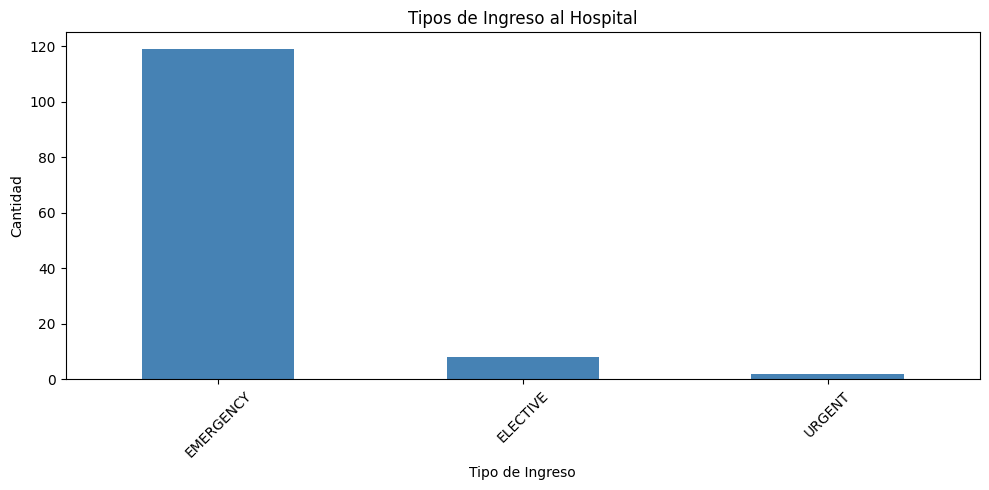

In [16]:
plt.figure(figsize=(10, 5))
admissions['admission_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Tipos de Ingreso al Hospital')
plt.xlabel('Tipo de Ingreso')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7. Análisis: mortalidad

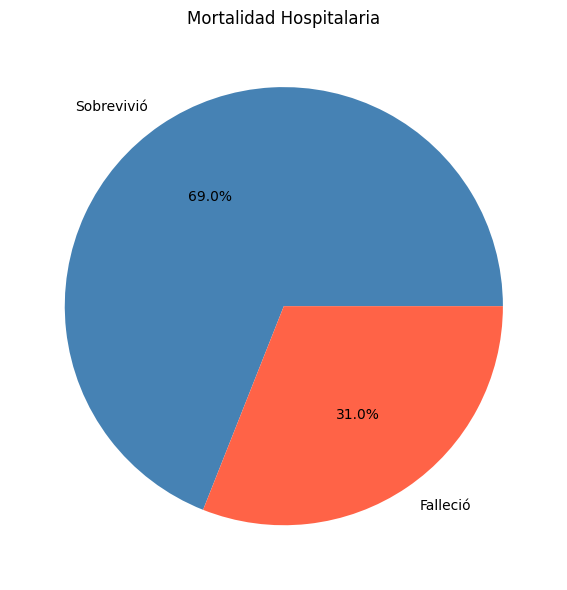

In [18]:
mortalidad = admissions['hospital_expire_flag'].value_counts()
etiquetas = ['Sobrevivió', 'Falleció']

plt.figure(figsize=(6, 6))
plt.pie(mortalidad, labels=etiquetas, autopct='%1.1f%%',
        colors=['steelblue', 'tomato'])
plt.title('Mortalidad Hospitalaria')
plt.tight_layout()
plt.show()

8. Diagnósticos más frecuentes

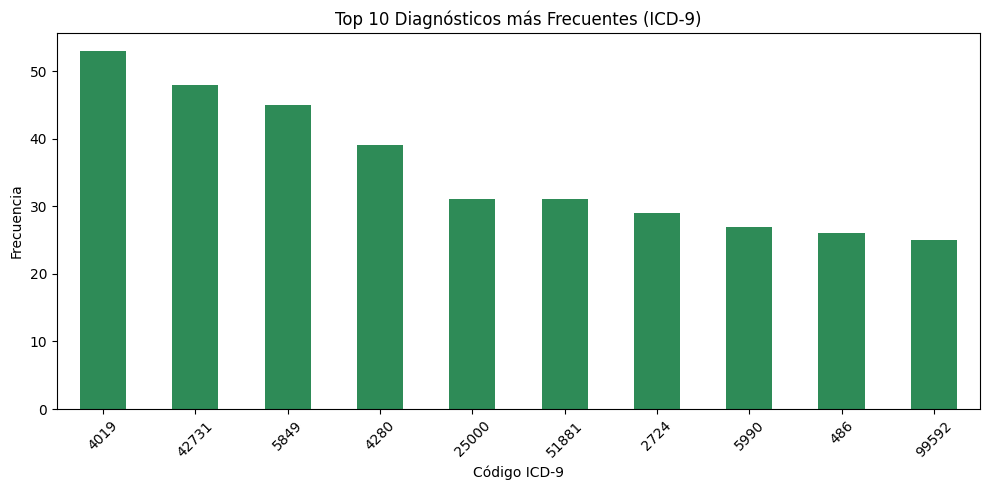

In [21]:
top_diagnosticos = diagnoses['icd9_code'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_diagnosticos.plot(kind='bar', color='seagreen')
plt.title('Top 10 Diagnósticos más Frecuentes (ICD-9)')
plt.xlabel('Código ICD-9')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("Columnas de DIAGNOSES:")
print(diagnoses.columns.tolist())

Columnas de DIAGNOSES:
['row_id', 'subject_id', 'hadm_id', 'seq_num', 'icd9_code']
